In [ ]:
import numpy as np
import pandas as pd
import re
df = pd.read_csv("sentiment_translated_comments_cWnra1270ss_04-09-2023.csv")

In [ ]:
df.head()

,channelId,videoId,textDisplay,textOriginal,authorDisplayName,authorProfileImageUrl,authorChannelUrl,authorChannelId,canRate,viewerRating,likeCount,publishedAt,updatedAt,parentId,commentId,Sentiment
0,UCbtlMIfdRVxPXZ1nI8NBN2A,cWnra1270ss,Quem nao acha graça no igor é muito mau amado ...,Who does not find fun in Igor is very bad love...,thamires frança,https://yt3.ggpht.com/w_508_TDfkSDvg-IjZqNnWz5...,http://www.youtube.com/channel/UC-NfU-FhFcqBfe...,{'value': 'UC-NfU-FhFcqBfem0k0ivCnA'},True,none,0,2023-09-04T02:20:22Z,2023-09-04T02:20:22Z,NaN,UgwrECjz6ajFcaUPIrt4AaABAg,"{'neg': 0.244, 'neu': 0.489, 'pos': 0.266, 'co..."
1,UCbtlMIfdRVxPXZ1nI8NBN2A,cWnra1270ss,kkkkkkkkkkkkkkkkkkkkk,kkkkkkkkkkkkkkkkkkk,REINALDO BATISTA DA SILVA,https://yt3.ggpht.com/ytc/AOPolaTffpm_nJCENxx1...,http://www.youtube.com/channel/UColB10RBtD1rH5...,{'value': 'UColB10RBtD1rH5TVpnCMxIg'},True,none,0,2023-08-29T13:27:57Z,2023-08-29T13:27:57Z,NaN,Ugy7J3T1gTUgrWXc34l4AaABAg,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound..."
2,UCbtlMIfdRVxPXZ1nI8NBN2A,cWnra1270ss,Saudades Robertinho,I miss Robertinho,Pali Ativa,https://yt3.ggpht.com/ytc/AOPolaQJakDO4xq9TUSO...,http://www.youtube.com/channel/UC296vRhM9ToGTM...,{'value': 'UC296vRhM9ToGTMx33jlE6dg'},True,none,0,2023-08-16T01:56:59Z,2023-08-16T01:56:59Z,NaN,UgxM1SoQO01spfuS4Tl4AaABAg,"{'neg': 0.444, 'neu': 0.556, 'pos': 0.0, 'comp..."
3,UCbtlMIfdRVxPXZ1nI8NBN2A,cWnra1270ss,o Coisa Nossa precisa liberar os vídeos sem ce...,OUR THING NEEDS TO LAUNCH VIDEOS UNTENSED FOR ...,Bonyeck Louzeiro,https://yt3.ggpht.com/mPgmsJDT7Cx4O_HYAr7REOV2...,http://www.youtube.com/channel/UCOAaEIAyyY8ylh...,{'value': 'UCOAaEIAyyY8ylhiFcgQEAEw'},True,none,0,2023-08-16T00:42:03Z,2023-08-16T00:42:03Z,NaN,Ugw-mV53_afQM7MCzAZ4AaABAg,"{'neg': 0.134, 'neu': 0.685, 'pos': 0.181, 'co..."
4,UCbtlMIfdRVxPXZ1nI8NBN2A,cWnra1270ss,"<a href=""http://www.youtube.com/results?search...",#Backeobertinho#Volisadinha,Nill Sousa,https://yt3.ggpht.com/ytc/AOPolaRmnJhFqebJPG7h...,http://www.youtube.com/channel/UCt0Kf6BRWFtF7_...,{'value': 'UCt0Kf6BRWFtF7_AvlweSzaw'},True,none,0,2023-08-13T04:24:33Z,2023-08-13T04:24:33Z,NaN,UgxezW69G-19ZsNkZF14AaABAg,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound..."


In [ ]:
df.Sentiment.head()

0    {'neg': 0.244, 'neu': 0.489, 'pos': 0.266, 'co...
1    {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...
2    {'neg': 0.444, 'neu': 0.556, 'pos': 0.0, 'comp...
3    {'neg': 0.134, 'neu': 0.685, 'pos': 0.181, 'co...
4    {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...
Name: Sentiment, dtype: object

In [ ]:
# Converter a coluna 'Sentiment' que está em formato de string para dicionário
df['Sentiment'] = df['Sentiment'].apply(eval)

# Expandir a coluna 'Sentiment' em várias colunas
sentiments = df['Sentiment'].apply(pd.Series)

# Renomear a coluna 'compound' para 'comp'
sentiments = sentiments.rename(columns={'compound': 'comp'})

# Juntar as novas colunas ao dataset original
df = pd.concat([df, sentiments], axis=1)

# Selecionar as colunas desejadas
df_new = df[['videoId', 'textDisplay', 'textOriginal', 'authorDisplayName', 'likeCount', 'neg', 'neu', 'pos', 'comp', 'publishedAt', 'updatedAt']]

# Se você quiser adicionar uma coluna ID
df_new.insert(0, 'id', range(1, len(df_new) + 1))

# Salvar o novo dataframe como csv
df_new.to_csv('new_sentiment_translated_comments_cWnra1270ss_04-09-2023', index=False)

In [ ]:
df_new.head()

,id,videoId,textDisplay,textOriginal,authorDisplayName,likeCount,neg,neu,pos,comp,publishedAt,updatedAt
0,1,cWnra1270ss,Quem nao acha graça no igor é muito mau amado ...,Who does not find fun in Igor is very bad love...,thamires frança,0,0.244,0.489,0.266,0.1489,2023-09-04T02:20:22Z,2023-09-04T02:20:22Z
1,2,cWnra1270ss,kkkkkkkkkkkkkkkkkkkkk,kkkkkkkkkkkkkkkkkkk,REINALDO BATISTA DA SILVA,0,0.000,1.000,0.000,0.0000,2023-08-29T13:27:57Z,2023-08-29T13:27:57Z
2,3,cWnra1270ss,Saudades Robertinho,I miss Robertinho,Pali Ativa,0,0.444,0.556,0.000,-0.1531,2023-08-16T01:56:59Z,2023-08-16T01:56:59Z
3,4,cWnra1270ss,o Coisa Nossa precisa liberar os vídeos sem ce...,OUR THING NEEDS TO LAUNCH VIDEOS UNTENSED FOR ...,Bonyeck Louzeiro,0,0.134,0.685,0.181,0.1007,2023-08-16T00:42:03Z,2023-08-16T00:42:03Z
4,5,cWnra1270ss,"<a href=""http://www.youtube.com/results?search...",#Backeobertinho#Volisadinha,Nill Sousa,0,0.000,1.000,0.000,0.0000,2023-08-13T04:24:33Z,2023-08-13T04:24:33Z


In [ ]:
df_new.comp.describe()

count    353.000000
mean       0.213586
std        0.424783
min       -0.938200
25%        0.000000
50%        0.000000
75%        0.599400
max        0.986300
Name: comp, dtype: float64

In [ ]:
np.median(df_new.comp)

0.0

In [ ]:
df_new.isnull().sum()

id                   0
videoId              0
textDisplay          0
textOriginal         0
authorDisplayName    0
likeCount            0
neg                  0
neu                  0
pos                  0
comp                 0
publishedAt          0
updatedAt            0
dtype: int64

In [ ]:
# Filtrar o DataFrame para excluir linhas onde 'comp' é zero
df_new = df_new[df_new['comp'] != 0]

# Se você quiser redefinir o índice depois da filtragem
# df_new.reset_index(drop=True, inplace=True)

In [ ]:
df_new.count()

id                   210
videoId              210
textDisplay          210
textOriginal         210
authorDisplayName    210
likeCount            210
neg                  210
neu                  210
pos                  210
comp                 210
publishedAt          210
updatedAt            210
dtype: int64

In [ ]:
np.median(df_new.comp)

0.4933

In [ ]:
df_new.comp.describe()

count    210.000000
mean       0.359028
std        0.501430
min       -0.938200
25%       -0.045150
50%        0.493300
75%        0.755125
max        0.986300
Name: comp, dtype: float64

In [ ]:
%matplotlib inline
import seaborn as sns

<Axes: >

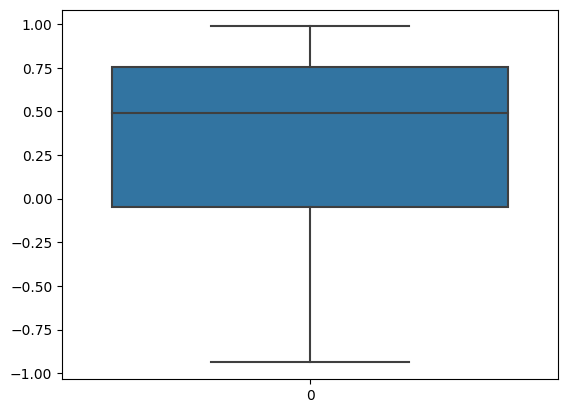

In [ ]:
sns.boxplot(df_new.comp)

<Axes: ylabel='comp'>

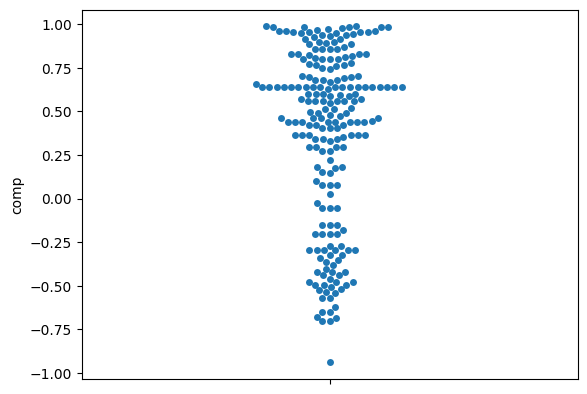

In [ ]:
sns.swarmplot(df_new.comp, orient="v")

<Axes: ylabel='comp'>

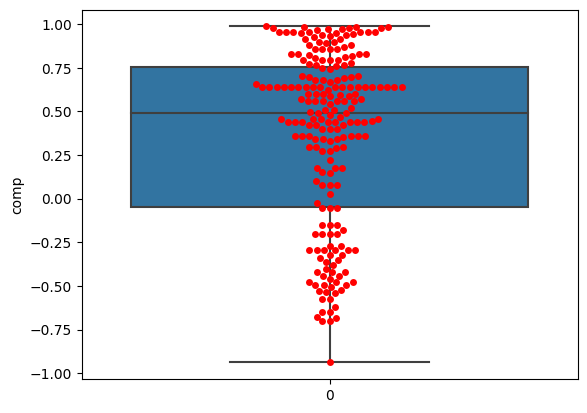

In [ ]:
sns.swarmplot(df_new.comp, orient="v", color="red")
sns.boxplot(df_new.comp, orient="v")

In [ ]:
def classify_sentiment(value):
    if value > 0.7:
        return 'A'  # Muito Positivo
    elif value > 0.05:
        return 'B'  # Positivo
    elif value >= -0.05:
        return 'C'  # Neutro
    else:
        return 'D'  # Muito Negativo

df_new['rating'] = df_new['comp'].apply(classify_sentiment)

In [ ]:
df_new.head()

,id,videoId,textDisplay,textOriginal,authorDisplayName,likeCount,neg,neu,pos,comp,publishedAt,updatedAt,rating
0,1,cWnra1270ss,Quem nao acha graça no igor é muito mau amado ...,Who does not find fun in Igor is very bad love...,thamires frança,0,0.244,0.489,0.266,0.1489,2023-09-04T02:20:22Z,2023-09-04T02:20:22Z,B
2,3,cWnra1270ss,Saudades Robertinho,I miss Robertinho,Pali Ativa,0,0.444,0.556,0.000,-0.1531,2023-08-16T01:56:59Z,2023-08-16T01:56:59Z,D
3,4,cWnra1270ss,o Coisa Nossa precisa liberar os vídeos sem ce...,OUR THING NEEDS TO LAUNCH VIDEOS UNTENSED FOR ...,Bonyeck Louzeiro,0,0.134,0.685,0.181,0.1007,2023-08-16T00:42:03Z,2023-08-16T00:42:03Z,B
5,6,cWnra1270ss,Cadê o Robertinho???? 😢,Where's Robertinho ????😢,Beatriz Freire,0,0.504,0.496,0.000,-0.6199,2023-08-08T15:40:26Z,2023-08-08T15:40:26Z,D
6,7,cWnra1270ss,E o orégano ?😔,And the oregano? 😔,Kairo,0,0.000,0.755,0.245,0.0772,2023-08-08T02:56:04Z,2023-08-08T02:56:04Z,B


In [ ]:
df_d = df_new.loc[df_new['rating'] == 'D']
df_d = df_d.sort_values(by='comp', ascending=True)
df_d.head(10)

,id,videoId,textDisplay,textOriginal,authorDisplayName,likeCount,neg,neu,pos,comp,publishedAt,updatedAt,rating
293,294,cWnra1270ss,KD O ROBERTINHOOOOOO ? 😭😭😭😭😭,Kd the Robertinhoooooo?😭😭😭😭😭,EDSIMON005,4,0.544,0.456,0.000,-0.9382,2023-07-14T22:47:42Z,2023-07-14T22:47:42Z,D
226,227,cWnra1270ss,o segredo tava esse tempo todo na thumb 😱,The secret was all this time on thumb 😱,milhodas k,0,0.367,0.633,0.000,-0.7003,2023-07-15T00:38:32Z,2023-07-15T00:38:32Z,D
329,330,cWnra1270ss,"O pessoal passa o dia observando a futil vida alheia nas redes enquanto preenche as próprias redes com a sua vida sem graça e mediocre e acha que a existência não é miserável. Se vc não tem 24 anos e não é um possível nobelista, não é milionário, sua existência é sim miserável, sejam bem vindos.","People spend the day by observing the futile life of others in networks while filling their own networks with their dull and mediocre life and thinks that existence is not miserable.If you are not 24 years old and are not a possible noblelist, not a millionaire, its existence is miserable, welcome.",KiulUser,0,0.150,0.799,0.051,-0.7003,2023-07-16T01:05:48Z,2023-07-16T12:20:06Z,D
161,162,cWnra1270ss,"Minha vida é tão bosta, que não posso comer farinha de trigo, sou intolerante e nem a merda do caju. KKKKKKKKKKKKKKK VTNC universo","My life is so shit that I can't eat wheat flour, I'm intolerant, nor the cashew shit.Kkkkkkkkkkkkkkkk vtnc universe",Alan Zuconelli,0,0.204,0.796,0.000,-0.6825,2023-07-15T05:00:50Z,2023-07-15T05:00:50Z,D
316,317,cWnra1270ss,Mas o melhor canal de culinária não era o Bounasera?,But wasn't the best cooking channel Buonasera?,Elvis Delgado,1,0.431,0.569,0.000,-0.6759,2023-07-14T22:24:36Z,2023-07-14T22:24:36Z,D
278,279,cWnra1270ss,Cadê o velho?<br>Robertinho faz mt falta 😢,Where's the old man?\nRobertinho is missing 😢,João Carlos,1,0.431,0.569,0.000,-0.6486,2023-07-14T23:06:33Z,2023-07-14T23:06:33Z,D
95,96,cWnra1270ss,Como o Robertinho faz falta... 😢,How the Robertinho is missing ... 😢,Bruna Baratela,37,0.469,0.531,0.000,-0.6486,2023-07-16T00:17:59Z,2023-07-16T00:17:59Z,D
5,6,cWnra1270ss,Cadê o Robertinho???? 😢,Where's Robertinho ????😢,Beatriz Freire,0,0.504,0.496,0.000,-0.6199,2023-08-08T15:40:26Z,2023-08-08T15:40:26Z,D
134,135,cWnra1270ss,Saudades do Robertinho 😢,I miss Robertinho 😢,Liz ASMR,0,0.610,0.390,0.000,-0.5719,2023-07-15T12:16:38Z,2023-07-15T12:16:38Z,D
81,82,cWnra1270ss,Eu tambem detesto pessoas Igor.,I also hate people Igor.,Claudia Gonçalves,0,0.481,0.519,0.000,-0.5719,2023-07-16T13:55:37Z,2023-07-16T13:55:37Z,D


In [ ]:
df_a = df_new.loc[df_new['rating'] == 'A']
df_a = df_a.sort_values(by='comp', ascending=False)
df_a.head()

,id,videoId,textDisplay,textOriginal,authorDisplayName,likeCount,neg,neu,pos,comp,publishedAt,updatedAt,rating
249,250,cWnra1270ss,Amo iguinho ❤❤❤❤❤,LOVE IGUINHO ❤❤❤❤❤❤,Katia,1,0.0,0.189,0.811,0.9863,2023-07-14T23:45:28Z,2023-07-14T23:45:28Z,A
275,276,cWnra1270ss,Amo vc Igor❤❤❤❤❤,I love you Igor❤❤❤❤❤❤,Catia Pasqualon,1,0.0,0.234,0.766,0.9854,2023-07-14T23:09:33Z,2023-07-14T23:09:33Z,A
281,282,cWnra1270ss,Amooooo 🎉 melhor combinação ❤❤❤❤❤,AMOOOOO 🎉 Best combination ❤❤❤❤❤,Debora Barcelos,1,0.0,0.223,0.777,0.9833,2023-07-14T23:03:21Z,2023-07-14T23:03:21Z,A
238,239,cWnra1270ss,Mano sem puxar saco <br>Pizza com Guaraná é muito bommm❤❤❤❤❤,Bro without pulling bag\nPizza with Guarana is very goodmm❤❤❤❤❤❤,Ana Julia💗,1,0.0,0.386,0.614,0.9808,2023-07-15T00:12:19Z,2023-07-15T00:12:19Z,A
342,343,cWnra1270ss,❤❤❤❤❤,❤❤❤❤❤❤,amanda ferreira,1,0.0,0.192,0.808,0.9803,2023-07-14T23:09:09Z,2023-07-14T23:09:09Z,A


In [ ]:
# Criando um padrão regex para considerar acentuação
pattern = r'guaran[áa]|ant[áa]rtica'

# Filtrar as linhas que contêm "guarana" ou "antartica" (com ou sem acentuação)
df_d_filtered = df_d[df_d['textDisplay'].str.contains(pattern, case=False, flags=re.IGNORECASE, na=False)]
pd.set_option('display.max_colwidth', None)
df_d_filtered.head(100)

,id,videoId,textDisplay,textOriginal,authorDisplayName,likeCount,neg,neu,pos,comp,publishedAt,updatedAt,rating
243,244,cWnra1270ss,Esse guaraná zero açúcar é horrível vamos ser sinceros,This zero sugar guarana is horrible let's be sincere,ReiMajestade👑,0,0.265,0.530,0.205,-0.2023,2023-07-14T23:53:10Z,2023-07-14T23:53:10Z,D
236,237,cWnra1270ss,"foi demitido até onde sei, tá fora do Guaraná infelizemnte. Ele q dava graça pro canal","I was fired as far as I know, it is out of guarana unfortunately.He gave the channel grace",Meu Canal,1,0.161,0.714,0.125,-0.2023,2023-07-15T00:17:09Z,2023-07-15T00:17:09Z,D
284,285,cWnra1270ss,Comprei uma pizza e um guaraná de 1l que me cobraram 10$,I bought a pizza and a 1L guarana that charged me 10 $,Jonas de Souza Oficial,0,0.130,0.870,0.000,-0.2023,2023-07-14T23:00:35Z,2023-07-14T23:00:35Z,D


In [ ]:
df_d_filtered.textDisplay.head(100)

243                                    Esse guaraná zero açúcar é horrível vamos ser sinceros
236    foi demitido até onde sei, tá fora do Guaraná infelizemnte. Ele q dava graça pro canal
284                                  Comprei uma pizza e um guaraná de 1l que me cobraram 10$
Name: textDisplay, dtype: object

In [ ]:
df_a_filtered = df_a[df_a['textDisplay'].str.contains(pattern, case=False, flags=re.IGNORECASE, na=False)]
df_a_filtered.head(100)

,id,videoId,textDisplay,textOriginal,authorDisplayName,likeCount,neg,neu,pos,comp,publishedAt,updatedAt,rating
238,239,cWnra1270ss,Mano sem puxar saco <br>Pizza com Guaraná é muito bommm❤❤❤❤❤,Bro without pulling bag\nPizza with Guarana is very goodmm❤❤❤❤❤❤,Ana Julia💗,1,0.000,0.386,0.614,0.9808,2023-07-15T00:12:19Z,2023-07-15T00:12:19Z,A
340,341,cWnra1270ss,pô aqui e guaraná tem ser coração verde 💚💚💚,here and Guarana has to be green heart 💚💚💚,ceginnn,1,0.000,0.373,0.627,0.9571,2023-07-14T23:10:22Z,2023-07-14T23:10:22Z,A
164,165,cWnra1270ss,"Melhor que temos! ❤<br>Assisti tomando um Guaranazin, o sabor da felicidade ❤","Better we have!❤\nI watched taking a Guaranazin, the taste of happiness ❤",Luciele Leal,4,0.000,0.441,0.559,0.9450,2023-07-15T03:42:03Z,2023-07-15T03:42:03Z,A
40,41,cWnra1270ss,"Eu sempre fico com a boca seca de vontade d tomar guaraná, quando vejo esses vídeos 😂😂😂","I always have a dry mouth of willing to take guarana, when I see these videos 😂😂😂",Deisi Dassa,0,0.135,0.594,0.271,0.8271,2023-07-19T03:04:01Z,2023-07-19T03:04:01Z,A
46,47,cWnra1270ss,"meu sonho é comprar esse copo do guaraná, é lindo demaaaaaaaaaaaais!!!","My dream is to buy this glass of Guarana, it's beautiful Demaaaaaaaaaaaaaaais !!!",Laísa Brigantini,0,0.000,0.619,0.381,0.7767,2023-07-18T17:53:07Z,2023-07-18T17:53:07Z,A
